In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [18]:
DATASET_PATH = "dataset.csv"


df = pd.read_csv(DATASET_PATH)
print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,Timestamp,1. What is your year of study?,2. What is your gender?,3. How often do you have difficulty falling asleep at night?,"4. On average, how many hours of sleep do you get on a typical day?",5. How often do you wake up during the night and have trouble falling back asleep?,6. How would you rate the overall quality of your sleep?,7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?,"8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?","9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?,"11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?","12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?",13. How often do you engage in physical activity or exercise?,14. How would you describe your stress levels related to academic workload?,15. How would you rate your overall academic performance (GPA or grades) in the past semester?
0,10/24/2024 16:51:15,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average
1,10/24/2024 16:51:51,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good
2,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average
3,10/24/2024 16:53:00,Third year,Male,Often (5-6 times a week),More than 8 hours,Sometimes (3-4 times a week),Poor,Often,Often,Rarely (1-2 times a month),Minor impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Every day,Extremely high stress,Excellent
4,10/24/2024 16:53:25,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Very good,Always,Sometimes,Sometimes (1-2 times a week),Moderate impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),Low stress,Average


In [19]:
# Column Rename
col_renames = {
    'Timestamp': 'Timestamp',
    '1. What is your year of study?': 'Study_Year',
    '2. What is your gender?': 'Gender',
    '3. How often do you have difficulty falling asleep at night? ': 'Sleep_Difficulty',
    '4. On average, how many hours of sleep do you get on a typical day?': 'Sleep_Hours',
    '5. How often do you wake up during the night and have trouble falling back asleep?': 'Night_Awakenings',
    '6. How would you rate the overall quality of your sleep?': 'Sleep_Quality',
    '7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?': 'Concentration_Diff',
    '8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?': 'Daytime_Fatigue',
    '9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?': 'Missed_Classes',
    '10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?': 'Assignment_Impact',
    '11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?': 'Screen_Time',
    '12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?': 'Caffeine',
    '13. How often do you engage in physical activity or exercise?': 'Exercise',
    '14. How would you describe your stress levels related to academic workload?': 'Stress_Level',
    '15. How would you rate your overall academic performance (GPA or grades) in the past semester?': 'Academic_Performance'
}

df = df.rename(columns=col_renames)
# Drop unused features
df = df.drop(columns=["Timestamp", "Study_Year", "Gender", "Night_Awakenings", "Sleep_Quality", "Daytime_Fatigue", "Concentration_Diff", "Missed_Classes", "Assignment_Impact", "Academic_Performance"])
print(df.columns.tolist())

['Sleep_Difficulty', 'Sleep_Hours', 'Screen_Time', 'Caffeine', 'Exercise', 'Stress_Level']


Encoding

In [20]:
freq_mapping = {
    'Never': 0, 
    'Rarely (1-2 times a week)': 1, 
    'Sometimes (3-4 times a week)': 2, 
    'Often (5-6 times a week)': 3, 
    'Every day': 4,
    'Every night': 4
}

sleep_mapping = {
    'Less than 4 hours': 1, 
    '4-5 hours': 2, 
    '6-7 hours': 3, 
    '7-8 hours': 4, 
    'More than 8 hours': 5
}

stress_mapping = {
    'No stress': 0, 
    'Low stress': 1, 
    'High stress': 2, 
    'Extremely high stress': 3
}

X = pd.DataFrame()
X['Sleep_Hours'] = df['Sleep_Hours'].map(sleep_mapping)
X['Caffeine'] = df['Caffeine'].map(freq_mapping)
X['Screen_Time'] = df['Screen_Time'].map(freq_mapping)
X['Exercise'] = df['Exercise'].map(freq_mapping)
X['Stress_Level'] = df['Stress_Level'].map(stress_mapping)

In [21]:
df['Insomnia_Risk'] = df['Sleep_Difficulty'].isin(['Often (5-6 times a week)', 'Every night']).astype(int)
y = df['Insomnia_Risk']

In [22]:
print(df['Insomnia_Risk'].value_counts())

Insomnia_Risk
1    735
0     56
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  RandomForestClassifier(class_weight='balanced', random_state=42))
])

In [25]:
params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth':    [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [26]:
grid_search = GridSearchCV(pipeline, params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=1)

In [27]:
grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mor

In [28]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

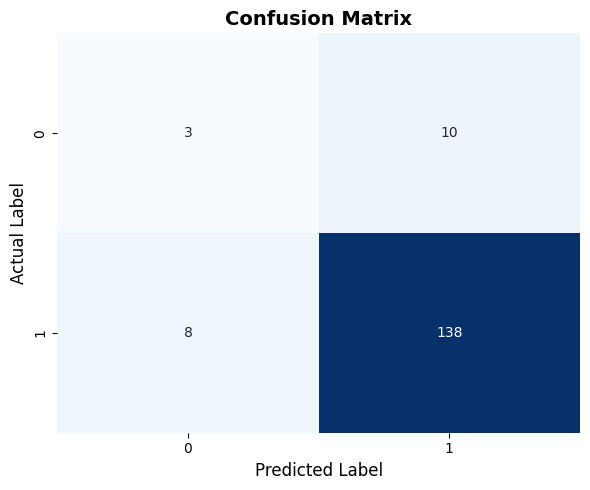

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.tight_layout()
plt.show()

In [30]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.23      0.25        13
           1       0.93      0.95      0.94       146

    accuracy                           0.89       159
   macro avg       0.60      0.59      0.59       159
weighted avg       0.88      0.89      0.88       159



In [31]:
y_train_pred = best_model.predict(X_train) 

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')

print("Train F1:", round(train_f1, 4))
print("Test F1:", round(test_f1, 4))

Train F1: 0.7205
Test F1: 0.5944


In [32]:
with open('Random_Forest_Model.pkl', 'wb') as f:
    pickle.dump(best_model, f)